# Can News Sentiment Help Predict Tomorrow's ETF Direction?

This notebook asks a simple question: can today's market information and news sentiment help us predict whether a sector ETF will go up during the next trading session? We use the existing 11-sector-ETF data and the daily RavenPack news summary.

We compare two versions of the model. The first uses only recent market behavior. The second adds news sentiment. We test each year in the future, after training on earlier years, so the evaluation resembles how a model would be used in real life. This is a first-pass baseline, not the final model.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'data_collection').exists():
    if (REPO_ROOT.parent / 'data_collection').exists():
        REPO_ROOT = REPO_ROOT.parent
    else:
        raise FileNotFoundError('Run this notebook from the repository root or data_collection/.')

DATA_DIR = REPO_ROOT / 'data_collection'
OUTPUT_DIR = REPO_ROOT / 'model_outputs'
MARKET_PATH = DATA_DIR / 'market_daily_df.csv'
NEWS_PATH = DATA_DIR / 'news_daily_df.csv'
METRICS_PATH = OUTPUT_DIR / 'walk_forward_metrics.csv'
PREDICTIONS_PATH = OUTPUT_DIR / 'holdout_predictions.csv'

START_DATE = pd.Timestamp('2020-01-01')
END_DATE = pd.Timestamp('2025-12-31')
TEST_YEARS = [2022, 2023, 2024, 2025]

BASELINE_FEATURES = [
    'return_lag_1',
    'return_lag_5',
    'return_lag_20',
    'return_mean_5',
    'return_mean_20',
    'return_std_20',
    'volume_log_lag_1',
]

SENTIMENT_FEATURES = [
    'mean_event_sentiment_score',
    'positive_event_share',
    'negative_event_share',
    'news_volume_log',
    'source_count_log',
]

print(f'Project folder: {REPO_ROOT}')
print(f'Market data file: {MARKET_PATH}')
print(f'News data file: {NEWS_PATH}')

Project folder: C:\Users\dongx\OneDrive\文档\Group\siads-699-sentiment-analysis-sp500
Market data file: C:\Users\dongx\OneDrive\文档\Group\siads-699-sentiment-analysis-sp500\data_collection\market_daily_df.csv
News data file: C:\Users\dongx\OneDrive\文档\Group\siads-699-sentiment-analysis-sp500\data_collection\news_daily_df.csv


In [2]:
def sigmoid(values: np.ndarray) -> np.ndarray:
    """Turn any number into a probability between 0 and 1."""
    clipped = np.clip(values, -35.0, 35.0)
    return 1.0 / (1.0 + np.exp(-clipped))


def fit_logistic(
    x_train: np.ndarray,
    y_train: np.ndarray,
    learning_rate: float = 0.08,
    iterations: int = 2500,
    l2: float = 0.05,
) -> tuple[np.ndarray, float]:
    """Learn weights that turn the input features into up/down probabilities.

    Each row is one ETF-day. The function returns one weight per feature
    plus an intercept, which is the model's starting point before features
    are considered."""
    # Gradient descent slowly adjusts the weights to reduce prediction error.
    weights = np.zeros(x_train.shape[1], dtype=float)
    intercept = 0.0
    n_rows = float(len(y_train))

    for _ in range(iterations):
        probabilities = sigmoid(x_train @ weights + intercept)
        residual = probabilities - y_train
        weights -= learning_rate * ((x_train.T @ residual) / n_rows + l2 * weights)
        intercept -= learning_rate * residual.mean()

    return weights, intercept


def standardize(
    x_train: pd.DataFrame, x_test: pd.DataFrame
) -> tuple[np.ndarray, np.ndarray]:
    """Put features on a comparable scale using training data only.

    This makes a return feature and a news-count feature easier for the
    optimizer to compare. It also keeps test-year information separate."""
    # Using training statistics only prevents information from the test year
    # from influencing the model before the test begins.
    train_mean = x_train.mean(axis=0)
    train_std = x_train.std(axis=0, ddof=0).replace(0.0, 1.0)
    train_scaled = ((x_train - train_mean) / train_std).to_numpy(dtype=float)
    test_scaled = ((x_test - train_mean) / train_std).to_numpy(dtype=float)
    return train_scaled, test_scaled


def roc_auc(y_true: np.ndarray, scores: np.ndarray) -> float:
    """Measure how often an up day receives a higher score than a down day.

    A score near 0.5 means the ranking is about as useful as a coin flip."""
    positives = y_true == 1
    negatives = y_true == 0
    n_positive = int(positives.sum())
    n_negative = int(negatives.sum())
    if n_positive == 0 or n_negative == 0:
        return float('nan')

    order = np.argsort(scores, kind='mergesort')
    sorted_scores = scores[order]
    ranks = np.empty(len(scores), dtype=float)
    start = 0
    while start < len(scores):
        end = start + 1
        while end < len(scores) and sorted_scores[end] == sorted_scores[start]:
            end += 1
        ranks[order[start:end]] = (start + 1 + end) / 2.0
        start = end

    positive_rank_sum = ranks[positives].sum()
    return float((positive_rank_sum - n_positive * (n_positive + 1) / 2.0) / (n_positive * n_negative))


def classification_metrics(
    y_true: np.ndarray, probabilities: np.ndarray
) -> dict[str, float]:
    """Calculate the three headline measures used in the report.

    AUC evaluates ranking, F1 balances missed up days and false alarms,
    and directional accuracy is simply the share of correct predictions."""
    predictions = (probabilities >= 0.5).astype(int)
    true_positive = int(((predictions == 1) & (y_true == 1)).sum())
    false_positive = int(((predictions == 1) & (y_true == 0)).sum())
    false_negative = int(((predictions == 0) & (y_true == 1)).sum())
    denominator = 2 * true_positive + false_positive + false_negative
    f1 = 0.0 if denominator == 0 else 2.0 * true_positive / denominator
    return {
        'auc_roc': roc_auc(y_true, probabilities),
        'f1': float(f1),
        'directional_accuracy': float((predictions == y_true).mean()),
    }

In [3]:
# Load the two clean, daily tables produced by the earlier notebooks.
market = pd.read_csv(MARKET_PATH, parse_dates=['session_date'])
news = pd.read_csv(NEWS_PATH, parse_dates=['session_date'])

# Keep the same date window in both files. The final after-hours news row
# can extend past the last market date, so it is excluded here.
market = market.loc[market['session_date'].between(START_DATE, END_DATE)].copy()
news = news.loc[news['session_date'].between(START_DATE, END_DATE)].copy()
news = news.drop_duplicates('session_date')

# Attach the same daily news signal to each ETF traded that day.
panel = market.merge(news, on='session_date', how='left', validate='many_to_one')
panel = panel.sort_values(['ticker', 'session_date']).reset_index(drop=True)
grouped = panel.groupby('ticker', group_keys=False)

# Market-only signals: recent returns and recent volatility.
for lag in [1, 5, 20]:
    panel[f'return_lag_{lag}'] = grouped['daily_return'].shift(lag)

panel['return_mean_5'] = grouped['daily_return'].transform(
    lambda values: values.shift(1).rolling(5, min_periods=5).mean()
)
panel['return_mean_20'] = grouped['daily_return'].transform(
    lambda values: values.shift(1).rolling(20, min_periods=20).mean()
)
panel['return_std_20'] = grouped['daily_return'].transform(
    lambda values: values.shift(1).rolling(20, min_periods=20).std(ddof=0)
)

# Use yesterday's volume, plus a few simple news-volume measures.
panel['volume_log'] = np.log1p(panel['volume'].clip(lower=0))
panel['volume_log_lag_1'] = panel.groupby('ticker')['volume_log'].shift(1)
panel['news_volume_log'] = np.log1p(panel['event_record_count'].clip(lower=0))
panel['source_count_log'] = np.log1p(panel['unique_source_count'].clip(lower=0))

# The first 20 sessions do not have enough history for rolling features.
# We also remove rows without a known next-session outcome.
required = BASELINE_FEATURES + SENTIMENT_FEATURES + ['fwd_1d_positive']
panel = panel.dropna(subset=required).copy()
panel['target'] = panel['fwd_1d_positive'].astype(int)

print(f'Rows ready for modeling: {len(panel):,}')
print(f'Date range: {panel["session_date"].min().date()} to {panel["session_date"].max().date()}')
print(f'Tickers: {panel["ticker"].nunique()}')
display(panel[['session_date', 'ticker', 'target'] + BASELINE_FEATURES[:3] + SENTIMENT_FEATURES[:2]].head())

Rows ready for modeling: 16,357
Date range: 2020-01-31 to 2025-12-30
Tickers: 11


,session_date,ticker,target,return_lag_1,return_lag_5,return_lag_20,mean_event_sentiment_score,positive_event_share
20,2020-01-31,XLB,1,-0.006239,-0.007146,-0.011723,-0.028697,0.403030
21,2020-02-03,XLB,1,-0.022060,-0.021594,-0.016145,-0.150609,0.204301
22,2020-02-04,XLB,1,0.020996,0.011292,-0.004354,0.060043,0.446809
23,2020-02-05,XLB,0,0.017675,0.003214,-0.001177,0.052064,0.406977
24,2020-02-06,XLB,0,0.018537,-0.006239,0.003536,0.025848,0.410714


In [4]:
# These are the two model versions we want to compare.
model_features = {
    'Market-only model': BASELINE_FEATURES,
    'Market + news sentiment model': BASELINE_FEATURES + SENTIMENT_FEATURES,
}
metric_rows = []
prediction_rows = []

# For each test year, train only on earlier dates and then evaluate on
# that untouched future year. This is our simple walk-forward test.
for test_year in TEST_YEARS:
    train_mask = panel['session_date'] < pd.Timestamp(str(test_year) + '-01-01')
    test_mask = panel['session_date'].dt.year == test_year
    train = panel.loc[train_mask]
    test = panel.loc[test_mask]
    if train.empty or test.empty:
        continue

    y_train = train['target'].to_numpy(dtype=int)
    y_test = test['target'].to_numpy(dtype=int)

    for model_name, feature_columns in model_features.items():
        # Scale using the training portion, fit the model, and predict the
        # next year without letting future information leak backward.
        x_train, x_test = standardize(train[feature_columns], test[feature_columns])
        weights, intercept = fit_logistic(x_train, y_train)
        probabilities = sigmoid(x_test @ weights + intercept)
        metrics = classification_metrics(y_test, probabilities)

        for metric, score in metrics.items():
            metric_rows.append({'model': model_name, 'fold': test_year, 'metric': metric, 'score': score})

        predictions = (probabilities >= 0.5).astype(int)
        for row, probability, prediction in zip(test.itertuples(index=False), probabilities, predictions):
            prediction_rows.append({
                'model': model_name,
                'fold': test_year,
                'session_date': row.session_date.date().isoformat(),
                'ticker': row.ticker,
                'y_true': int(row.target),
                'y_pred': int(prediction),
                'y_prob': float(probability),
            })

    # This simple benchmark always predicts 'up'. A real model should beat
    # it before we claim that the features are useful.
    always_up_probabilities = np.ones(len(test), dtype=float)
    always_up_metrics = classification_metrics(y_test, always_up_probabilities)
    for metric, score in always_up_metrics.items():
        metric_rows.append({'model': 'Always predict up', 'fold': test_year, 'metric': metric, 'score': score})
    for row in test.itertuples(index=False):
        prediction_rows.append({
            'model': 'Always predict up',
            'fold': test_year,
            'session_date': row.session_date.date().isoformat(),
            'ticker': row.ticker,
            'y_true': int(row.target),
            'y_pred': 1,
            'y_prob': 1.0,
        })

# Save compact outputs for the report notebook and show the average result
# across the four future-year tests.
metrics_df = pd.DataFrame(metric_rows)
predictions_df = pd.DataFrame(prediction_rows)
OUTPUT_DIR.mkdir(exist_ok=True)
metrics_df.to_csv(METRICS_PATH, index=False)
predictions_df.to_csv(PREDICTIONS_PATH, index=False)

print(f'Wrote {METRICS_PATH.relative_to(REPO_ROOT)}')
print(f'Wrote {PREDICTIONS_PATH.relative_to(REPO_ROOT)}')
summary_df = (
    metrics_df.groupby(['model', 'metric'], as_index=False)['score']
    .agg(mean='mean', std='std')
    .sort_values(['metric', 'model'])
)
display(summary_df.style.format({'mean': '{:.4f}', 'std': '{:.4f}'}))

Wrote model_outputs\walk_forward_metrics.csv
Wrote model_outputs\holdout_predictions.csv


,model,metric,mean,std
0,Always predict up,auc_roc,0.5000,0.0000
3,Market + news sentiment model,auc_roc,0.4946,0.0194
6,Market-only model,auc_roc,0.4962,0.0148
1,Always predict up,directional_accuracy,0.5251,0.0293
4,Market + news sentiment model,directional_accuracy,0.5221,0.0324
7,Market-only model,directional_accuracy,0.5234,0.0267
2,Always predict up,f1,0.6882,0.0257
5,Market + news sentiment model,f1,0.6746,0.0363
8,Market-only model,f1,0.6787,0.0296


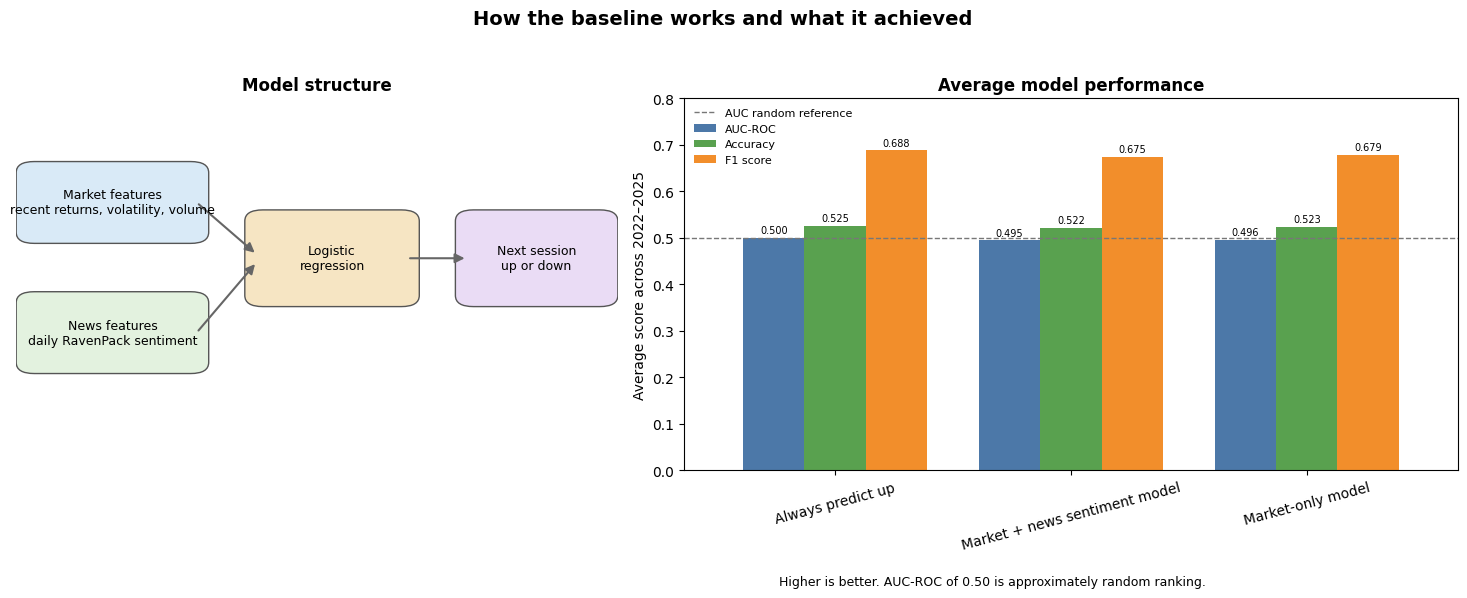

In [5]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig = plt.figure(figsize=(15, 6))
layout = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.35])

# Left: a simple picture of what goes into the model and what comes out.
flow_ax = fig.add_subplot(layout[0, 0])
flow_ax.set_xlim(0, 1)
flow_ax.set_ylim(0, 1)
flow_ax.axis('off')
flow_ax.set_title('Model structure', fontsize=12, fontweight='bold')

def add_box(axis, x, y, width, height, label, color):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle='round,pad=0.02,rounding_size=0.03',
        facecolor=color, edgecolor='#555555', linewidth=1,
    )
    axis.add_patch(box)
    axis.text(x + width / 2, y + height / 2, label, ha='center', va='center', fontsize=9)

add_box(flow_ax, 0.02, 0.63, 0.28, 0.18, 'Market features\nrecent returns, volatility, volume', '#d9eaf7')
add_box(flow_ax, 0.02, 0.28, 0.28, 0.18, 'News features\ndaily RavenPack sentiment', '#e3f2df')
add_box(flow_ax, 0.40, 0.46, 0.25, 0.22, 'Logistic\nregression', '#f6e5c3')
add_box(flow_ax, 0.75, 0.46, 0.23, 0.22, 'Next session\nup or down', '#eadcf5')

for start, end in [((0.30, 0.72), (0.40, 0.58)), ((0.30, 0.37), (0.40, 0.56)), ((0.65, 0.57), (0.75, 0.57))]:
    flow_ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=14, linewidth=1.5, color='#666666'))

# Right: compare average performance across the four future-year tests.
metric_ax = fig.add_subplot(layout[0, 1])
metric_plot = summary_df.pivot(index='model', columns='metric', values='mean')
metric_plot = metric_plot[['auc_roc', 'directional_accuracy', 'f1']].rename(
    columns={
        'auc_roc': 'AUC-ROC',
        'directional_accuracy': 'Accuracy',
        'f1': 'F1 score',
    }
)
metric_plot.plot(kind='bar', ax=metric_ax, width=0.78, color=['#4c78a8', '#59a14f', '#f28e2b'])
metric_ax.axhline(0.5, color='#777777', linestyle='--', linewidth=1, label='AUC random reference')
metric_ax.set_ylim(0, 0.8)
metric_ax.set_ylabel('Average score across 2022–2025')
metric_ax.set_xlabel('')
metric_ax.set_title('Average model performance', fontsize=12, fontweight='bold')
metric_ax.tick_params(axis='x', rotation=15)
metric_ax.legend(frameon=False, fontsize=8)
for container in metric_ax.containers:
    metric_ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)

fig.suptitle('How the baseline works and what it achieved', fontsize=14, fontweight='bold')
fig.text(0.68, 0.02, 'Higher is better. AUC-ROC of 0.50 is approximately random ranking.', ha='center', fontsize=9)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## Results and Interpretation

Across the four chronological holdout periods, the market-only model achieved an average AUC-ROC of 0.496, an F1 score of 0.679, and directional accuracy of 52.3%. After adding the RavenPack sentiment features, the corresponding averages were 0.495, 0.675, and 52.2%. The Always predict up comparison achieved 52.5% directional accuracy and an F1 score of 0.688.

Under this specification, the Market + news sentiment model therefore does not demonstrate incremental predictive value beyond the market-only model. Its performance is slightly lower than the market-only model on average, and the improvement observed in some individual years is not consistent across the full evaluation period.

This should be interpreted as a preliminary baseline result rather than evidence that financial-news sentiment is inherently uninformative. The model uses a relatively small set of linear features, pools all ETFs into one classifier, and relies on daily aggregated sentiment. More advanced work could test sector-specific effects, additional lags and rolling features, nonlinear models, company-level sentiment, and LLM-derived scores. No statistical significance tests or extensive hyperparameter tuning are performed here, so the results are descriptive and should not be interpreted as an investment recommendation.